# Equal band strengths, different dependence organization

The main target is weak **full-catalogue (289-SPI) MPI means** alongside informative SPI–SPI. A three-SPI control supports interpretation; it does not substitute for this test. The preceding all-proof-class experiment matched a native-update Jacobian gain but gave 89.6% classification for both means and SPI–SPI. Matching that scalar did not remove marginal information.

Here two stationary Gaussian MTS classes have equal coupling strengths and different organization across frequency bands. This is a controlled character contrast, not a recreation of the historical dynamical classes.

**Development result: the main target failed.** MPI means classify 15/16 validation recordings, while full-mean logistic regression and trees classify all 16. SPI–SPI and distributions also classify all 16. The validity-only and independently shuffled-edge controls are at chance. Squared lagged-correlation means reveal the classes despite the matched individual-band marginals. The reserved 64 held recordings remain unopened; this failure does not justify releasing them.

In [1]:
from pathlib import Path
import sys,json
ROOT=Path.cwd().resolve()
while not (ROOT/'pyproject.toml').exists() and ROOT!=ROOT.parent:ROOT=ROOT.parent
if str(ROOT) not in sys.path:sys.path.insert(0,str(ROOT))
import pandas as pd
%matplotlib inline
import matplotlib.pyplot as plt
from IPython.display import display
from scripts.build_band_swap import DATA,OUT
from scripts.plot_band_swap import plot,population
STAGE='development'
RESULT=OUT/STAGE
analysis=json.loads((RESULT/'analysis.json').read_text())
metrics=pd.read_csv(RESULT/'metrics.csv')
print('Evaluation stage:',STAGE)
display(metrics[metrics.method.isin(['mean','mean_full','mean_RBF','mean_trees','z','z_validity'])].round(3))

Evaluation stage:

development

,method,n,BA,low,high,chance
6,mean,16,0.938,0.812,1.0,0.5
8,z,16,1.000,1.000,1.0,0.5
9,z_validity,16,0.500,0.500,0.5,0.5
11,mean_full,16,1.000,1.000,1.0,0.5
12,mean_RBF,16,0.938,0.812,1.0,0.5
13,mean_trees,16,1.000,1.000,1.0,0.5


## Construction

Each recording has 16 channels and 1,000 observations. Three independent Gaussian Fourier fields occupy disjoint equal-width bands $(.035,.095)$, $(.17,.23)$ and $(.33,.39)$ cycles/sample, with translated smooth spectral envelopes and variance $1/3$ each. Their sum is the observed MTS. These are illustrative separated bands, chosen before p90 outcomes, not unique or physically privileged frequencies. The construction uses periodic stationary sampling, not a causal coupled-update model.

Within a band the population channel covariance is $C_g=\frac13[(1-\lambda)I+\lambda H_g]$, where $\lambda=.55$ and $(H_g)_{ij}=1$ when channels $i,j$ share one of four groups of four. The value .55 is a fixed moderate within-group correlation, not a fitted or optimal strength; the covariance is positive definite. A groups rows of a $4\times4$ grid, B groups columns, and C starts from A then swaps membership of channels 1/4 and 10/13 (zero-based), producing partial overlap. The patterns are channel permutations of one another.

**BCA** assigns B, C, A to low, middle, high frequency; **CBA** assigns C, B, A. The high-band pattern stays fixed while its strongest spatial correspondence moves between the lower bands. Random channel relabelling removes fixed sensor identities. Each band MPI has 20% of off-diagonal values equal to $.55/3$ and 80% zero: mean $.036\overline6$. Both classes also share their total zero-lag covariance, low-half covariance sum/maximum and high-band covariance.

For the three band-covariance probes, permutation symmetry and independent band draws give equal joint laws of marginal summaries across classes, including finite-sample estimates. **This does not prove equality of the 289-SPI mean distributions.** Other statistics can encode temporal structure in their means; that is the main empirical test.

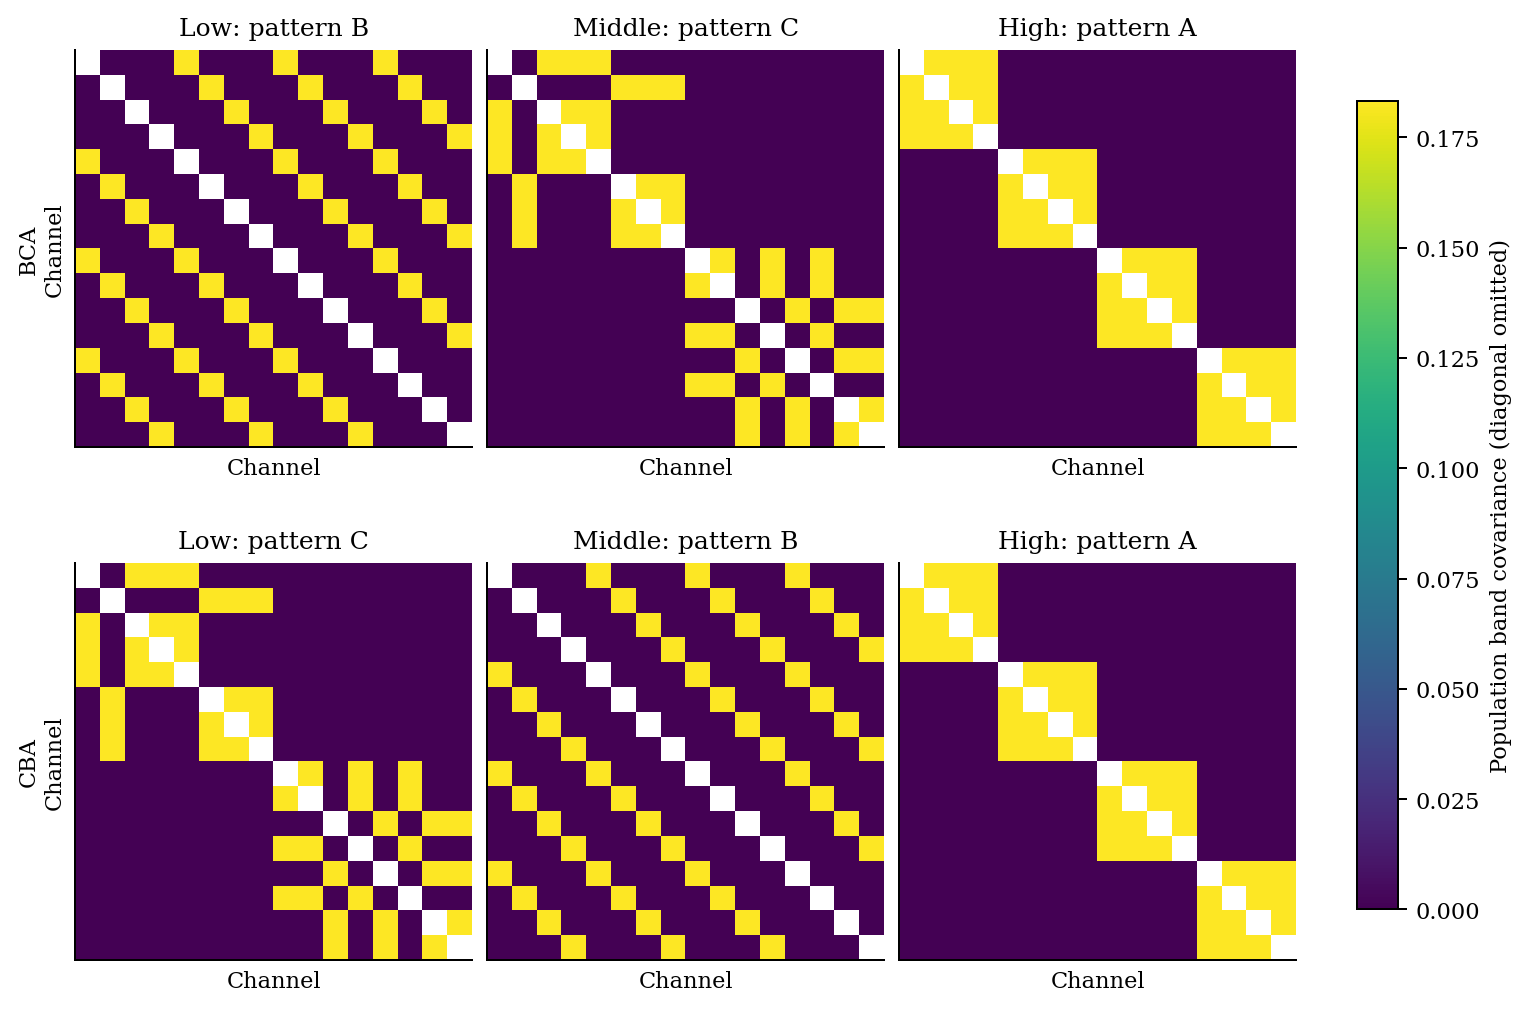

In [2]:
population();plt.show()

With $v_b$ the ordered off-diagonal entries of a band covariance, $z_{bc}=\mathrm{corr}(v_b,v_c)$ describes spatial correspondence. The population triples $(z_{LM},z_{LH},z_{MH})$ are $(-1/24,-1/4,3/8)$ for BCA and $(-1/24,3/8,-1/4)$ for CBA. Negative z means the bands tend to couple different pairs; the actual nonzero couplings are all positive. This is organization across bands, not causal cross-frequency coupling.

Imagine observers receiving the same coloured maps: one receives only each map's histogram, the other also sees which locations align across maps. For these three probes, the histogram observer cannot distinguish the classes; the alignment observer can. Whether the richer p90 catalogue supplies informative histograms remains open until tested.

## Full-catalogue test

Development blocks 0–23 train the models (48 recordings); blocks 24–31 validate them (16 recordings). Separate held blocks 32–63 provide 64 recordings and are released only after the development decision; final training then uses blocks 0–31. Each block contains one recording per class and shared nuisance channel ordering. Chance is 50%.

The primary features are the 289 off-diagonal means and 41,616 signed Pearson SPI–SPI values. Training-only preprocessing uses 95% validity selection, median imputation, SD scaling, clipping at five SD and at most 20 principal components; logistic regression fixes $C=1$. Full-mean logistic, RBF kernel and 500-tree classifiers check whether the PCA or linear classifier hides information. Distributions (mean, SD and 10/25/50/75/90 percentiles) are secondary. Missingness-only z and independently shuffled MPI edge profiles are diagnostic controls; the shuffle preserves MPI marginals but is not a realizable-MTS claim.

Intervals resample paired blocks with the fitted models fixed, omitting training uncertainty. Near-chance performance on a small validation set is not evidence of statistical equivalence. PCA/UMAP settings and seeds are fixed; both fit training recordings and transform validation or held recordings. No outcome selects the displayed recordings.

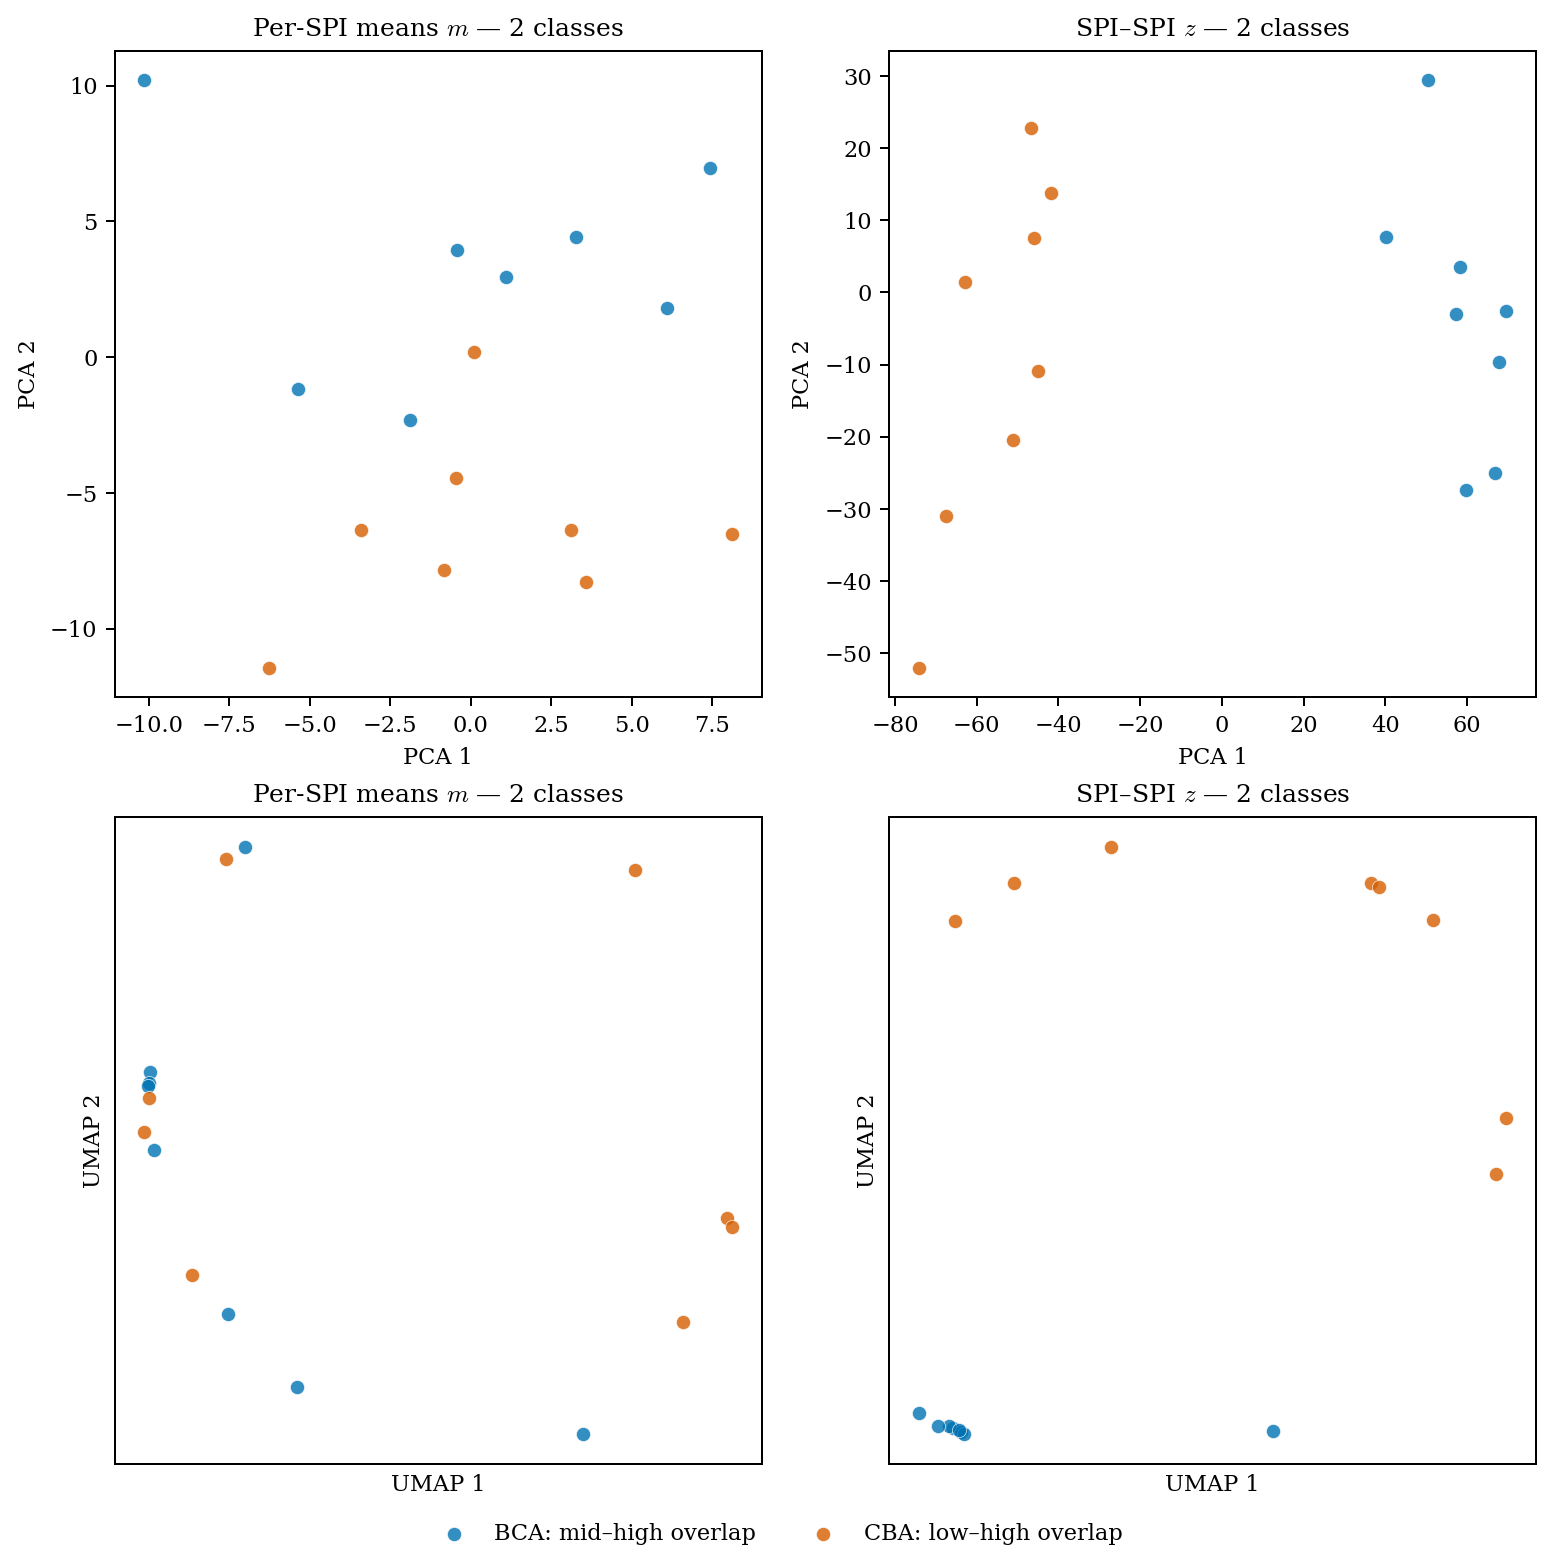

,comparison,difference,low,high
0,z - band_marginals,0.312,0.062,0.562
1,z - band_mean,0.438,0.188,0.689
2,z - band_z,0.000,0.000,0.000
3,z - distribution,0.000,0.000,0.000
4,z - mean,0.062,0.000,0.188
5,z - mean_RBF,0.062,0.000,0.188
6,z - mean_full,0.000,0.000,0.000
7,z - mean_trees,0.000,0.000,0.000
8,z - raw_Pearson,0.500,0.312,0.688
9,z - raw_covariance,0.438,0.250,0.625


,method,n,BA,low,high,chance
7,distribution,16,1.0,1.0,1.0,0.5
10,z_shuffled,16,0.5,0.5,0.5,0.5


,method,training_rank,feature,training_standardized_difference,evaluation_AUC
0,mean,1,corr_pearson_tau-3-sq,1.879,1.000
1,mean,2,corr_spearman_tau-3-sq,1.876,1.000
2,mean,3,corr_kendall_tau-3-sq,1.875,1.000
3,mean,4,phi_star_t-1_norm-1,-1.844,0.984
4,mean,5,phi_star_t-1_norm-0,-1.838,0.984


In [3]:
plot(STAGE,focused=False);plt.show()
display(pd.read_csv(RESULT/'paired.csv').round(3))
display(metrics[metrics.method.isin(['distribution','z_shuffled'])].round(3))
display(pd.read_csv(RESULT/'diagnostic-features.csv').query("method == 'mean'").head(5).round(3))

## Focused supporting control

The three explicit band-covariance SPIs are separate from p90. Their symmetry argument demonstrates the intended mechanism without establishing that the complete catalogue's means lack information.

In [4]:
display(metrics[metrics.method.isin(['band_mean','band_marginals','band_z','raw_covariance','raw_Pearson','spectra'])].round(3))

,method,n,BA,low,high,chance
0,band_z,16,1.000,1.000,1.000,0.5
1,band_marginals,16,0.688,0.438,0.938,0.5
2,raw_covariance,16,0.562,0.375,0.750,0.5
3,raw_Pearson,16,0.500,0.312,0.688,0.5
4,spectra,16,0.312,0.125,0.438,0.5
5,band_mean,16,0.562,0.311,0.812,0.5


## Scope and reproduction

A z advantage establishes utility for this construction and readouts, not generic strength invariance or causal interpretation. Informative full-catalogue means are negative evidence for the main target even if the focused control succeeds. SPI means are not inherently blind to dependence character; affine invariance of outer Pearson correlation does not imply invariance to a generator's coupling parameter.

Comparisons among representations have precedents in [representational similarity analysis](https://www.frontiersin.org/journals/systems-neuroscience/articles/10.3389/neuro.06.004.2008/full), and cross-layer overlap is an established [multiplex-network quantity](https://doi.org/10.1103/PhysRevE.89.032804). This example illustrates a mechanism, not novelty of overlap itself.

The immutable source manifest is in `data/representation/band-swap-261004/manifest.json`; the protocol is `configs/analysis/band-swap-261004.yaml`. `scripts/analyze_band_swap.py` audits source/member/config hashes, catalogue order and estimator seeding, then extracts features and evaluates the readouts. `sources.json` retains MPI hashes; `execution.json` records jobs and held-release status. This notebook renders cached numerical outputs without recomputing SPIs.

In [5]:
display(pd.DataFrame(analysis['diagnostics']).T.round(3))
print(json.dumps(analysis.get('development_goal',{}),indent=2))
print(json.dumps(json.loads((OUT/'execution.json').read_text()),indent=2))

,selected_features,components,explained_variance
band_z,3.0,3.0,1.000
band_marginals,21.0,20.0,1.000
raw_covariance,7.0,7.0,1.000
raw_Pearson,7.0,7.0,1.000
spectra,3.0,3.0,1.000
band_mean,3.0,3.0,1.000
mean,254.0,20.0,0.903
distribution,1814.0,20.0,0.785
z,32480.0,20.0,0.658
z_validity,1070.0,20.0,1.000


{
  "mean_readouts_weak": false,
  "z_detectable": true,
  "validity_weak": true,
  "all_pass": false,
  "qualification": "Exploratory small-validation gate, not a proof of marginal equality; inspect before held release"
}

{
  "stage": "development complete; main target failed; held remains sealed",
  "source_commit": "24a173f",
  "readout_commit": "67acb2b",
  "pyspi_commit": "65317c9c1fd5f12358b8ede09b7576ef001a76dd",
  "jobs": {
    "smoke": "180430259.gadi-pbs",
    "development": "180430729.gadi-pbs"
  },
  "remote_source": "/scratch/ql44/we2614/mts-spi-study/operations/sources/band-swap-24a173f",
  "remote_data": "/scratch/ql44/we2614/mts-spi-study/representation/synthetic/band-swap-261004",
  "expected_records": 128,
  "development_records": 64,
  "held_records": 64,
  "held_released": false,
  "primary_scope": "full289 SPI mean vector",
  "focused_development": {
    "n_validation": 16,
    "mean_BA": 0.5625,
    "z_BA": 1.0
  },
  "next": "Preserve negative result; test a sign-symmetry construction that matches squared-lag strengths before further full-catalogue computation.",
  "smoke_audit": {
    "complete": 2,
    "exit_status": 0,
    "wall_seconds": 1231,
    "compute_seconds": [
      117